# Домашнее задание 2. Линейные модели и регуляризация

В этом домашнем задании вы будете работать с набором данных по добыче газа: необходимо оценить, сколько денег будет приносить каждая из скважин, а также понять, какие факторы (параметры скважин) потенциально сильнее всего повлияют на объём добычи газа.
Ваша задача — пройти полный базовый цикл построения модели: от анализа и предобработки данных до обучения и улучшения линейной регрессии.

Итоговая цель — построить интерпретируемую и устойчивую модель, предсказывающую суточную добычу газа на основе геологических характеристик скважины.

**Описание признаков**

| Признак                | Описание                        |
| ---------------------- | ------------------------------- |
| `well_id`              | идентификатор скважины          |
| `porosity`             | пористость скважины             |
| `permeability`         | проницаемость скважины          |
| `acoustic_impedance`   | акустический импеданс           |
| `brittleness`          | коэффициент хрупкости скважины  |
| `organic_carbon`       | общий органический углерод      |
| `vitrinite_reflectance`| коэффициент отражения витринита |

**Целевая переменная**

`extr_per_day` — добыча газа в сутки (млн кубических футов).


In [1]:
# Импорт нужных библиотек и моделей,
# Добавляйте в ячейку все, что потребуется

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import joblib

### Задание 1
Первым делом **познакомимся с данными**, а заодно закрепим методы работы с Pandas.

0. Прочитайте файл, посмотрите на семпл и количество строк.
1. Проверьте наличие пропусков в данных и при необходимости обработайте их.  
2. Проверьте наличие выбросов  и ошибочных значений (тут полезно обратиться к смыслу признаков) и при необходимости почистите их.
3. Проверьте наличие дубликатов и при необходимости почистите их.
4. Подумайте, есть ли в данных неинформативные признаки, при необходимости удалите их.
5. Запишите наблюдения в виде небольшого вывода.

In [2]:
df = pd.read_csv('well_data.csv')

df

,well_id,porosity,permeability,acoustic_impedance,brittleness,organic_carbon,vitrinite_reflectance,extr_per_day
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832
...,...,...,...,...,...,...,...,...
195,196,11.95,3.13,2.97,67.18,0.80,2.06,3847.571003
196,197,17.99,9.87,3.38,44.32,0.98,2.08,5601.227131
197,198,12.12,2.27,3.52,57.07,-0.04,1.73,3409.575363
198,199,15.55,4.48,2.48,58.25,1.89,2.35,5087.592149


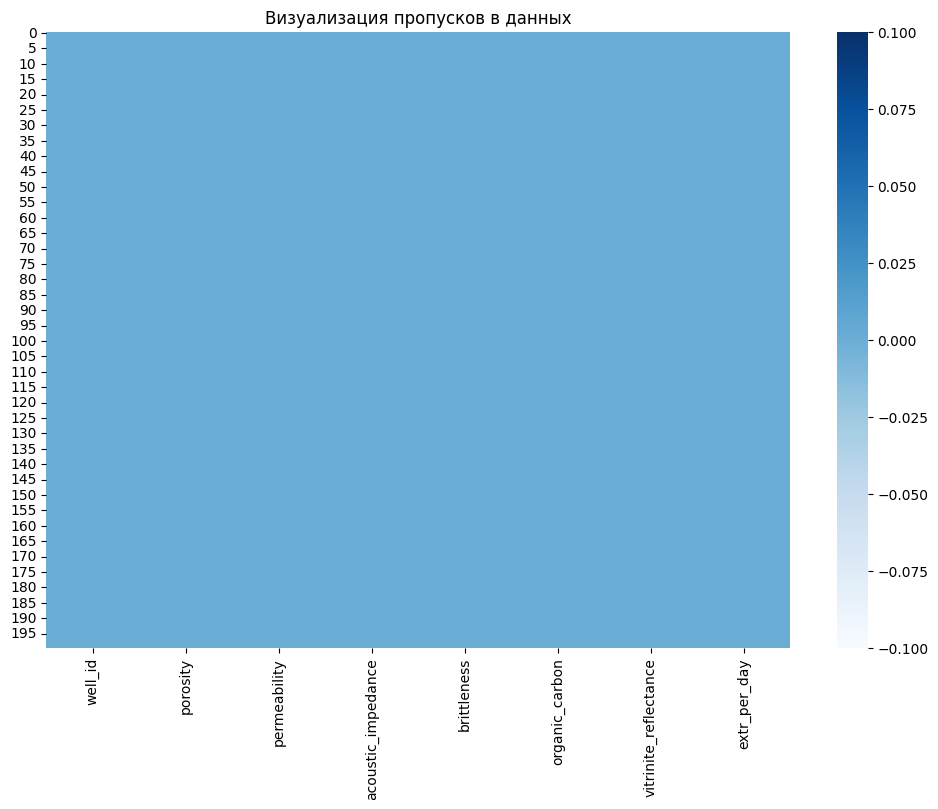

In [3]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cmap='Blues')
plt.title('Визуализация пропусков в данных')
plt.show()

In [4]:
for col in df.columns:
    null_count = df[col].isnull().sum()
    if null_count > 0:
        print(f'В столбце {col} {null_count} пропусков')
    else:
        print(f'В столбце {col} пропусков нет')

В столбце well_id пропусков нет
В столбце porosity пропусков нет
В столбце permeability пропусков нет
В столбце acoustic_impedance пропусков нет
В столбце brittleness пропусков нет
В столбце organic_carbon пропусков нет
В столбце vitrinite_reflectance пропусков нет
В столбце extr_per_day пропусков нет


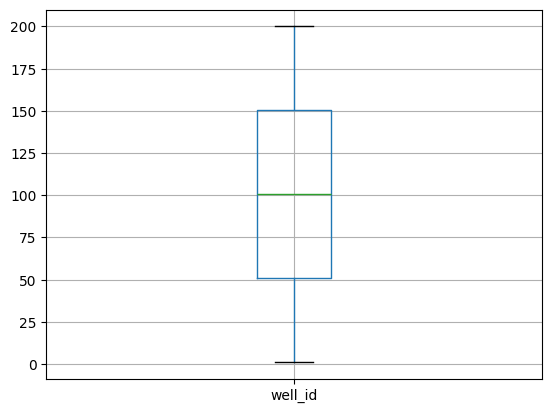

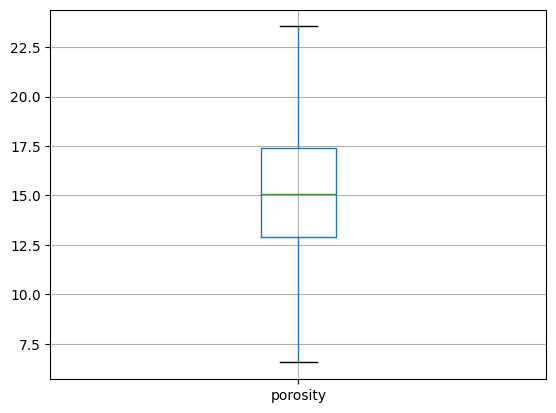

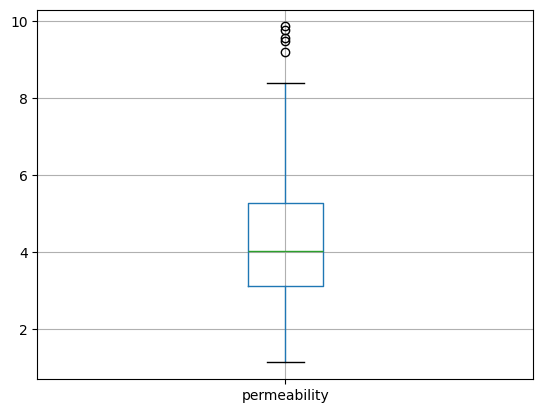

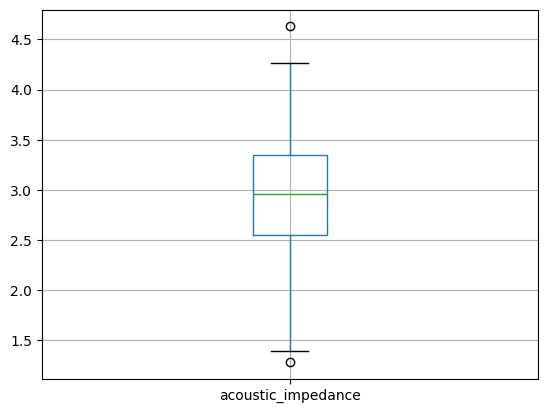

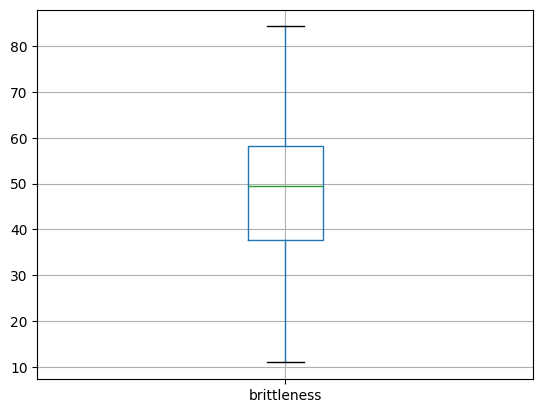

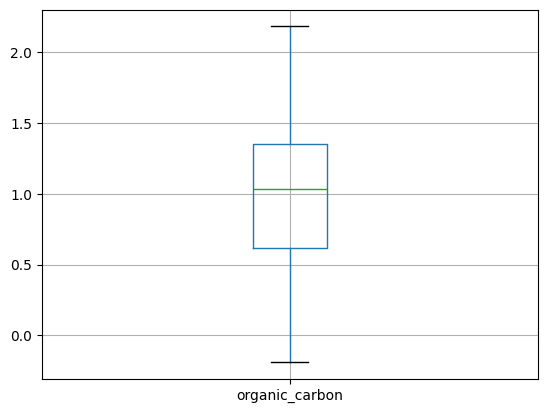

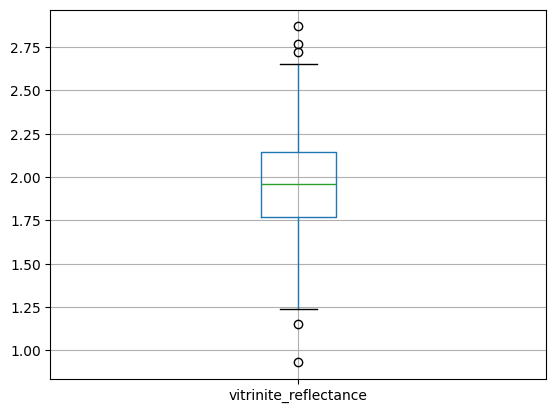

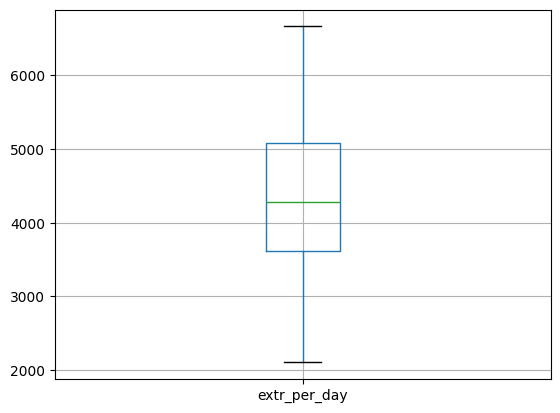

In [5]:
for col in df.select_dtypes(include=['int', 'float']).columns:
    df.boxplot(column=col)
    plt.show()

In [6]:
# полные дубликаты
full_duplicates = df.duplicated().sum()
if full_duplicates > 0:
    print(f'В данных есть полные дубликаты: {full_duplicates} шт.')
else:
    print('Полных дубликатов нет')

# дубликаты по well_id
well_id_duplicates = df['well_id'].duplicated().sum()
if well_id_duplicates > 0:
    print(f'В данных есть дубликаты по well_id: {well_id_duplicates} шт.')
else:
    print('Дубликатов по well_id нет')

Полных дубликатов нет
Дубликатов по well_id нет


In [7]:
df = df.drop('well_id', axis=1)

In [8]:
df.describe()

,porosity,permeability,acoustic_impedance,brittleness,organic_carbon,vitrinite_reflectance,extr_per_day
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,14.991150,4.330750,2.968850,48.161950,0.990450,1.964300,4311.219852
std,2.971176,1.731014,0.566885,14.129455,0.481588,0.300827,992.038414
min,6.550000,1.130000,1.280000,10.940000,-0.190000,0.930000,2107.139414
25%,12.912500,3.122500,2.547500,37.755000,0.617500,1.770000,3618.064513
50%,15.070000,4.035000,2.955000,49.510000,1.030000,1.960000,4284.687348
75%,17.402500,5.287500,3.345000,58.262500,1.350000,2.142500,5086.089761
max,23.550000,9.870000,4.630000,84.330000,2.180000,2.870000,6662.622385


**Выводы:**

1. Размерность датасета 200 строк и 8 столбцов

2. Пропусков и дубликатов (как полных, так и по идентификатору) не обнаружено

3. Анализ числовых переменных на выбросы и ошибки:

- `porosity` (пористость скважины) корректно

- `permeability` (проницаемость скважины) скорее всего, корректно

- `acoustic_impedance` (акустический индекс) скорее всего, корректно

- `brittleness` (коэффициент хрупкости скважины) корректно

- `organic_carbon` (общий органический углерод) минимальное значение -0.19, что физически невозможно (содержание органического углерода >= 0)

- `vitrinite_reflectance` (коэффициент отражения витринита) скорее всего, корректно

- `extr_per_day` (добыча газа в сутки (млн кубических футов) — завышено, но возможно

## Задание 2

Проведем небольшой **EDA.**

1. Посмотрите на распределение целевого признака `extr_per_day`.
2. Изучите распределения остальных признаков, а также парные зависимости (можете воспользоваться `pairplot` либо построить графики по отдельности).
3. Постройте матрицу корреляций, визуализируйте ее и проанализируйте наличие мультиколлинеарных признаков (в качестве порога можно взять ±0.7).
4. Зафиксируйте наблюдения в небольшом выводе.

In [9]:
df['extr_per_day'].describe()

,extr_per_day
count,200.000000
mean,4311.219852
std,992.038414
min,2107.139414
25%,3618.064513
50%,4284.687348
75%,5086.089761
max,6662.622385


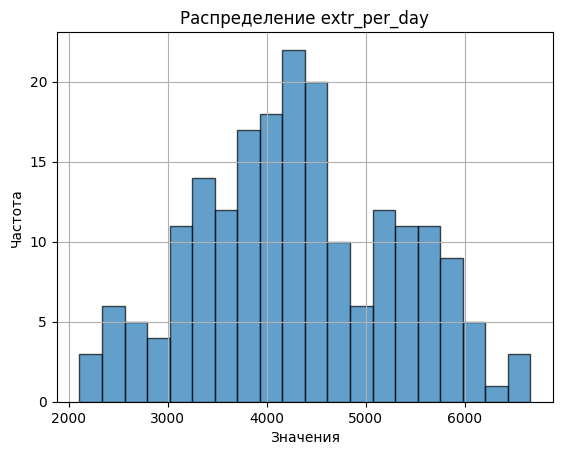

In [10]:
df['extr_per_day'].dropna().hist(bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.title('Распределение extr_per_day')
plt.show()

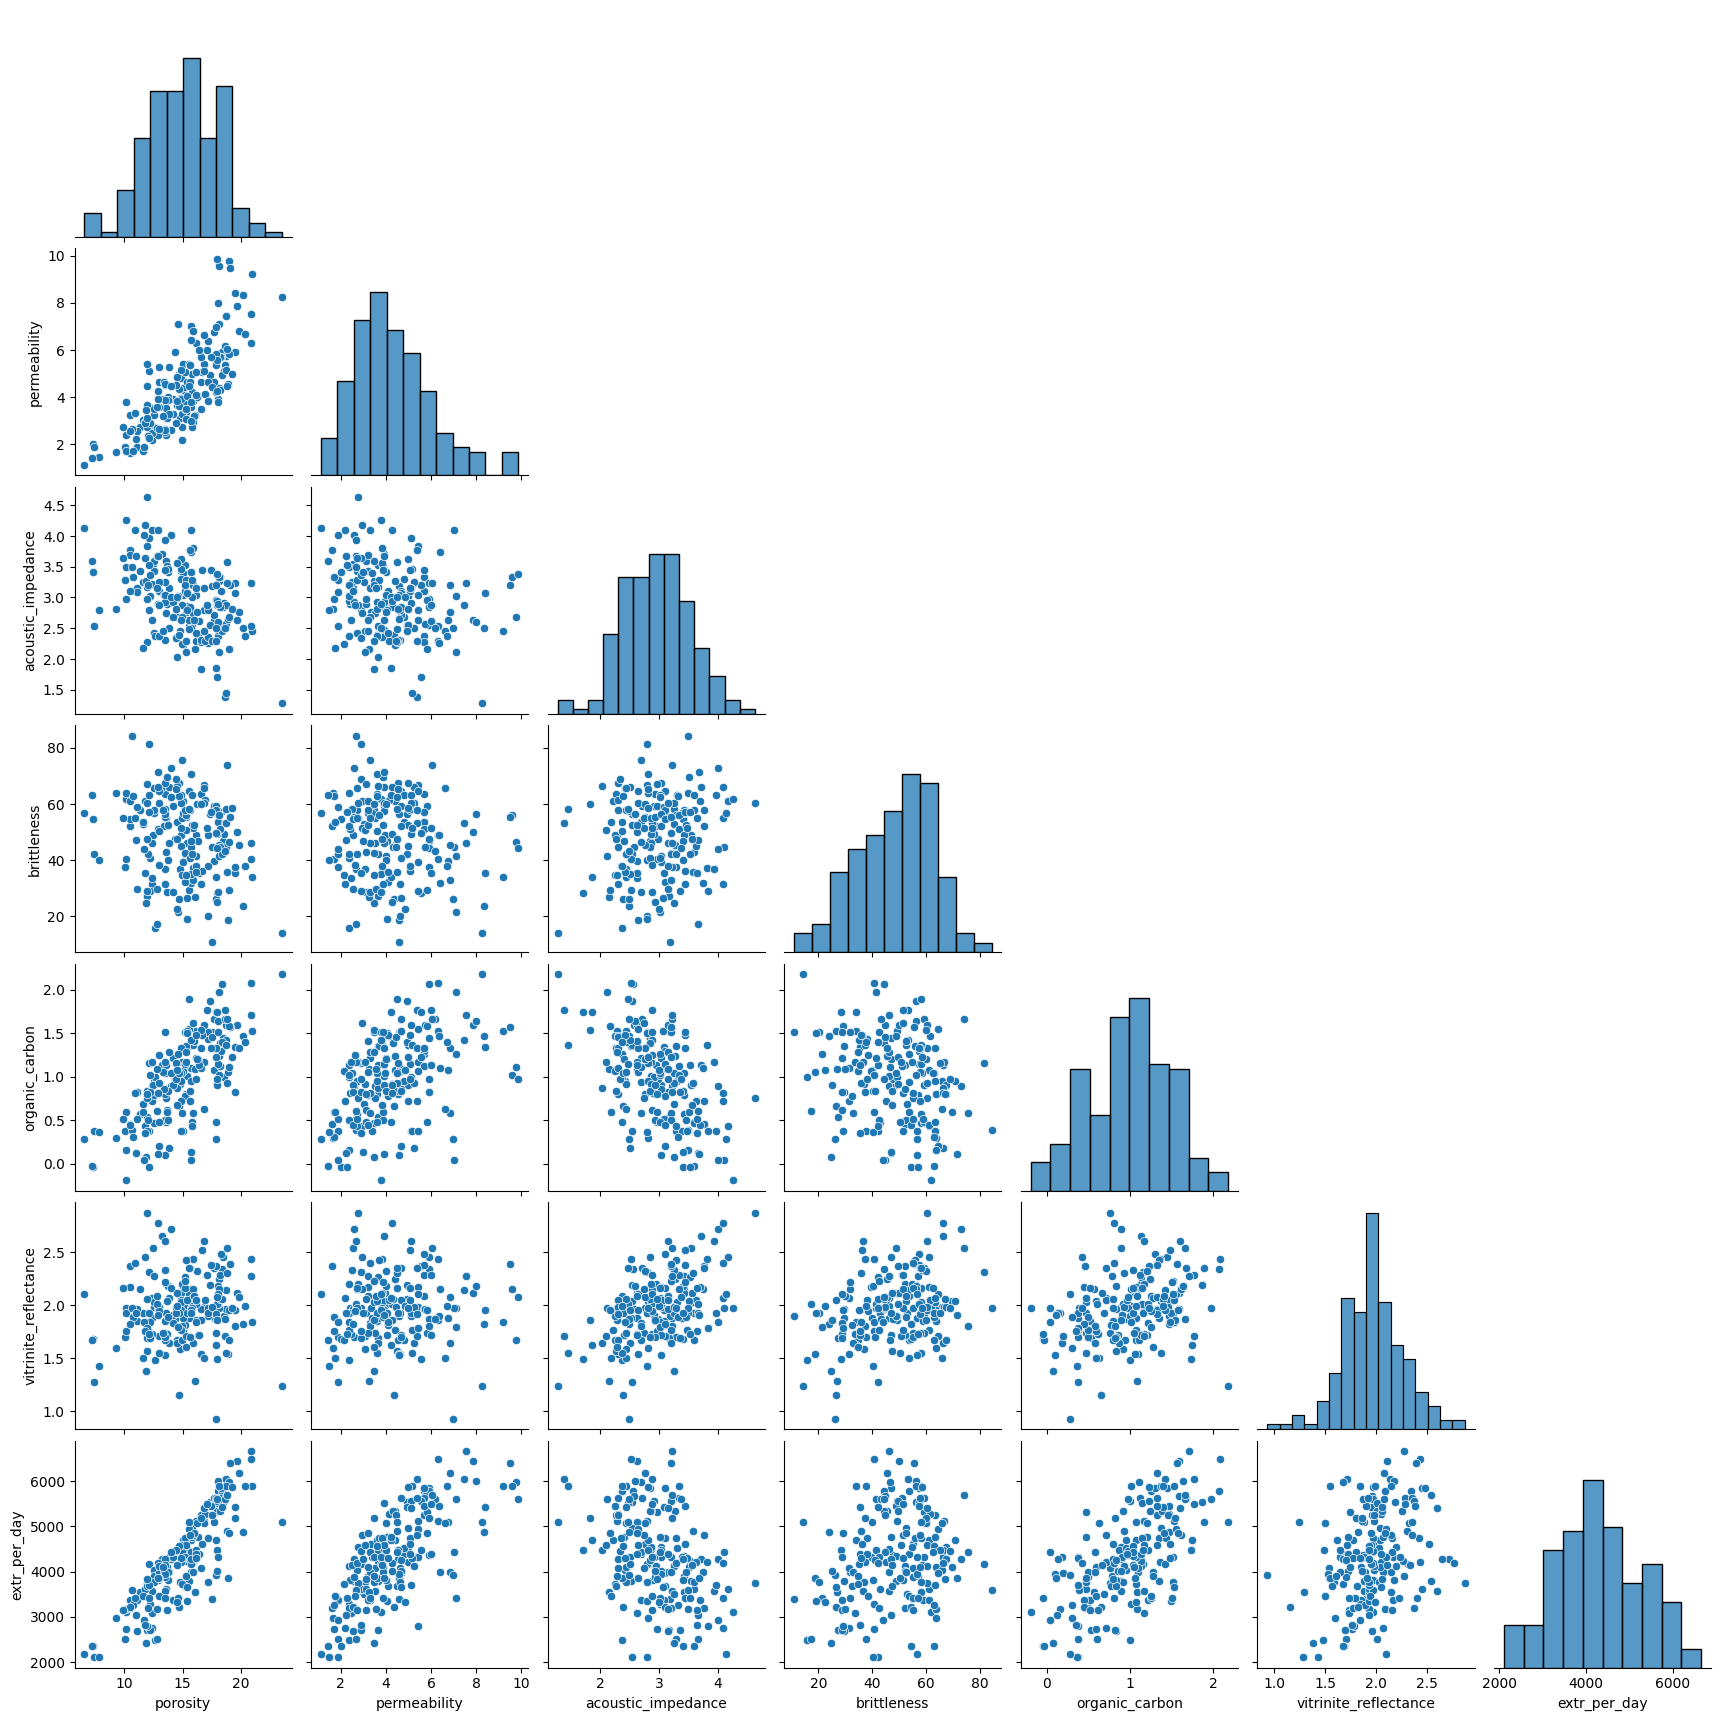

In [11]:
sns.pairplot(df, diag_kind='hist', corner=True)

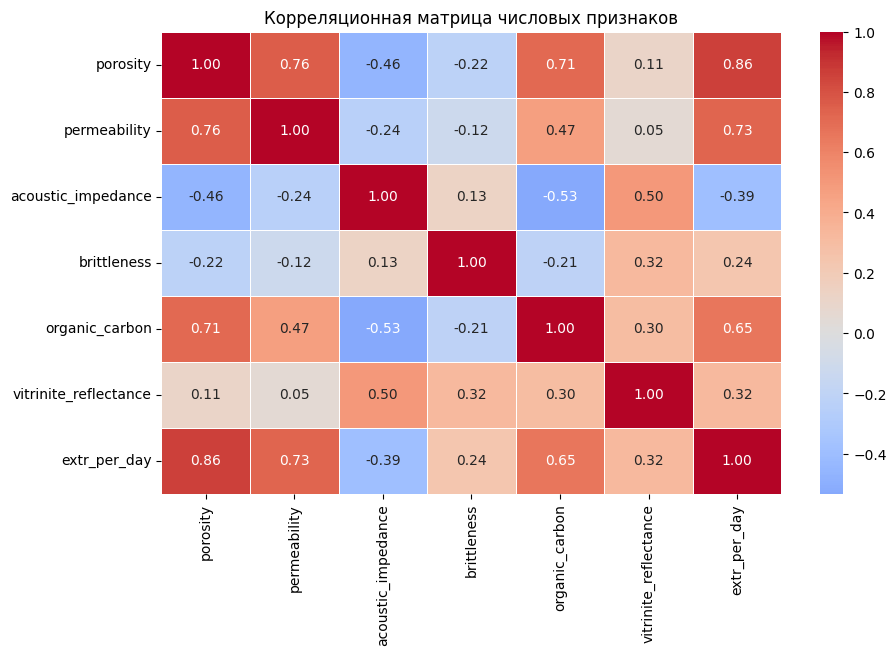

In [12]:
plt.figure(figsize=(10, 6))
corr_table = df.corr(numeric_only=True)
sns.heatmap(corr_table, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

**Выводы:**

Мы видим, что распределение `extr_per_day` приближено к нормальному - мода и среднее практически равны - можно использовать параметрические методы (линейная регрессия).
Разброс данных тоже небольшой: $\sigma / \mu \approx 0.23$.
50% значений между 3600 и 5100 (IQR).
Экстремальных выбросов нет.
Данные чистые, распределены хорошо.

$$
x_i = \frac{x_i - \mu}{\sigma}
$$

Pairplot демонстрирует отсутствие кластеров. Также присутствует ярко выраженная положительно направленная линейная зависимость между целевой переменной `extr_per_day` и `porosity` - корреляционная матрица подтверждает эту гипотезу - 0.86, признаки почти линейно зависимы.
Второй по значимости признак - `permeability`. Он коррелирует с целевой с силой 0.73. Присутствует небольшой правый хвост и выбросы.

Корреляционная матрица показывает нам коррелированность признаков между собой -  `porosity` и `permeability` почти линейно зависимы и сила связи между ними 0.76 - нужно выбрать какой-то один из признаков, а другой удалить, чтобы сделать модель численно стабильной. Так как `porosity` сильнее коррелирует с таргетом и у него распределение немного лучше, то оставим этот признак.
Также стоит удалить `organic_carbon` - он коррелирует с `porosity` с силой 0.71, порождая мультиколлениарность с таргетом.

## Задание 3

**Финально подготовим данные для модели.**

* По итогам EDA удалите сильно скоррелированные признаки, если они нашлись.
* Создайте матрицу признаков `X` и вектор таргета `y`.
* Разбейте данные на тренировочную и тестовую выборку, установите соотношение 80/20 и random_state=42.
* Выберите подходящий способ масштабирования или нормализации данных, примените его для обеих выборок. Также на этом этапе добавьте единичный столбец для вручную применяемых алгоритмов.
* Зафиксируйте все преобразования и обоснования в небольшом выводе.

In [13]:
# удаляем явную ошибку и сильно коррелированные столбцы
df = df[df['organic_carbon'] >= 0]
df_first = df.drop(['permeability', 'organic_carbon'], axis=1)

In [14]:
# пока что raw данные - не маштабированные
X_raw = df_first.drop('extr_per_day', axis=1)
y_raw = df_first['extr_per_day']

In [15]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw,
    test_size=0.2,
    random_state=42
)

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)  # fit ТОЛЬКО на train
X_test_scaled = scaler.transform(X_test_raw)        # transform на test

for i, col in enumerate(X_train_raw.columns):
    print(f'{col}: std={X_train_scaled[:, i].std():.2f}, mean={X_train_scaled[:, i].mean():.10f}')

# добавляем bias для ручных алгоритмов
X_train_scaled = np.column_stack([np.ones(X_train_scaled.shape[0]), X_train_scaled])
X_test_scaled = np.column_stack([np.ones(X_test_scaled.shape[0]), X_test_scaled])

porosity: std=1.00, mean=-0.0000000000
acoustic_impedance: std=1.00, mean=0.0000000000
brittleness: std=1.00, mean=0.0000000000
vitrinite_reflectance: std=1.00, mean=0.0000000000


**Выводы:**

Мы увидели явную ошибку для признака `organic_carbon` - общий органический углерод может быть >= 0, после чего почистили датасет от ошибки. Далее удалили столбцы 'permeability', 'organic_carbon' - чтобы избежать мультиколлениарности для численно стабильной модели. После чего разделили выборку на train и test, а затем маштабировали через StandardScaler, так как все нашли признаки - вещественные числа с хорошим распределением.

## Задание 4

**Приступаем к моделированию:**

* Первым делом предлагаем построить модель линейной регрессии по МНК: запишите формулу аналитического решения **в текстовой ячейке**, а затем реализуйте ее на Python и сравните результат с `LinearRegression` из `sklearn`.
* Оцените модель по метрикам $MSE$, $MAE$, $MAPE$ и $R^2$ на тренировочной и тестовой выборках. Проанализируйте полученные значения. Насколько модель хорошо предсказывает результат?
* Посмотрите на коэффициенты модели. Можно на основе этого сделать вывод о том, какие признаки наиболее важны при прогнозировании? Соотнесите коэффициенты и названия признаков. Есть ли связь с рассмотренными ранее коэффициентами корреляции?
* Напишите небольшой вывод касательно полученных результатов.

*Базовая формула:*

$$
\hat{\mathbf{w}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

где

$\hat{\mathbf{w}}$ - вектор весов, включая bias

$\mathbf{X}$ - матрица из признаков (с добавленным столбцом из единиц)

$\mathbf{y}$ - вектор целевой переменной

In [17]:
# 1. МНК своими руками (Normal Equation)
def normal_equation(X, y):
    """
    Аналитическое решение МНК: w = (X^T X)^(-1) X^T y
    """
    return np.linalg.inv(X.T @ X) @ X.T @ y


w_norm_eq = normal_equation(X_train_scaled, y_train.values)
print(f'Веса из Normal Equation:')
for i, col in enumerate(['bias'] + list(X_train_raw.columns)):
    print(f'{col}: {w_norm_eq[i]:.4f}')

# предсказания
y_pred_train_norm = X_train_scaled @ w_norm_eq
y_pred_test_norm = X_test_scaled @ w_norm_eq

# 2. LinearRegression из sklearn
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_scaled[:, 1:], y_train)  # без bias, sklearn сам добавит

print(f'\nВеса из sklearn:')
print(f'bias (intercept_): {sklearn_model.intercept_:.4f}')
for i, col in enumerate(X_train_raw.columns):
    print(f'{col}: {sklearn_model.coef_[i]:.4f}')

Веса из Normal Equation:
bias: 4322.1569
porosity: 831.9085
acoustic_impedance: -106.0531
brittleness: 388.2553
vitrinite_reflectance: 140.9684

Веса из sklearn:
bias (intercept_): 4322.1569
porosity: 831.9085
acoustic_impedance: -106.0531
brittleness: 388.2553
vitrinite_reflectance: 140.9684


In [18]:
# предсказания
y_pred_train = sklearn_model.predict(X_train_scaled[:, 1:])
y_pred_test = sklearn_model.predict(X_test_scaled[:, 1:])

# метрики
print('TRAIN:')
print(f'MSE: {mean_squared_error(y_train, y_pred_train):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}')
print(f'MAE: {mean_absolute_error(y_train, y_pred_train):.2f}')
print(f'MAPE: {np.mean(np.abs((y_train - y_pred_train)/y_train))*100:.2f}%')
print(f'R2: {r2_score(y_train, y_pred_train):.4f}\n')

print('TEST:')
print(f'MSE: {mean_squared_error(y_test, y_pred_test):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_test):.2f}')
print(f'MAPE: {np.mean(np.abs((y_test - y_pred_test)/y_test))*100:.2f}%')
print(f'R2: {r2_score(y_test, y_pred_test):.4f}')

TRAIN:
MSE: 57088.85
RMSE: 238.93
MAE: 181.49
MAPE: 4.31%
R2: 0.9395

TEST:
MSE: 41555.80
RMSE: 203.85
MAE: 131.53
MAPE: 2.80%
R2: 0.9565


**Выводы:**

Первый и самый главный вывод - наши данные очень легко подаются прогнозированию.

Никогда не видел в реальности, что простая линейная регрессия объясняет 96% дисперсии в данных - уровень синтетического датасета.

По коэффициентам (весам) модели.

Так как мы обучили модель уже на маштабированных данных, весам можно доверять.

Сильно выделяется признак `porosity` с весом 831.9085, остальные тоже важны.

* `porosity` 831.9085 главный драйвер добычи

* `acoustic_impedance` -106.0531 акустический импеданс обратно связан с проницаемостью

* `brittleness` 388.2553 хрупкость породы важна для гидроразрыва

* `vitrinite_reflectance` 140.9684 зрелость органического вещества

Метрики тоже отличные - как на train, так и на test - модель хорошо улавливает закономерности в данных

* MSE: 41555.80 сложно интерпретировать, так как ошибки возведены в квадрат - пример плохой метрики

* RMSE: 203.85 в среднем предсказания модели отличаются на +/-204 т/сут от фактических значений, 2 $\cdot$ RSME $\approx$ 400 - для некоторых объектов модель ошибается на 400 единиц, это говорит о наличии выбросов

* MAE: 131.53 в среднем модель ошибается на 131 в абсолютном выражении

* MAPE: 2.80% средняя ошибка всего 2.8%

* R2: 0.9565 модель объясняет 96% вариации целевой переменной - уровень продакшена

## Задание 5

**Попробуем усложнить:**

* Обучите классический градиентный спуск на подготовленных данных, реализованный вручную. Попробуйте подобрать такие гиперпараметры (шаг, количество итераций), чтобы решение максимально точно совпадало с МНК.
* Модифицируйте классический градиентный спуск, обновляя градиент не по всем обучающим примерам, а только по **случайной подвыборке (мини-батче)**. Сравните алгоритмы по качеству и скорости работы.
* Постройте для каждого эксперимента график сходимости на тренировочной и тестовой выборках и оцените модель по тем же метрикам.
* Напишите небольшой вывод. Удалось ли улучшить прогноз и возможно ли достигнуть более высокого качества, чем у МНК? В каких ситуациях что выбрать: классический градиентный спуск или мини-батчевый?

---

> Справка по градиентным методам:

* $\theta$ — вектор параметров модели
* $\eta$ — шаг обучения (learning rate)
* $\mathcal{L}(\theta; x_i, y_i)$ — функция потерь на одном объекте
* $N$ — размер датасета

**Классический (batch) градиентный спуск:** градиент считается по всему датасету.

$$
\theta_{t+1}
=
\theta_t
-
\eta
\cdot
\frac{1}{N}
\sum_{i=1}^{N}
\nabla_\theta \mathcal{L}(\theta_t; x_i, y_i)
$$

**Стохастический градиентный спуск (SGD):** градиент считается по одному случайному объекту.

$$
\theta_{t+1}
=
\theta_t
-
\eta
\cdot
\nabla_\theta \mathcal{L}(\theta_t; x_i, y_i),
$$

где $i$ — случайно выбранный индекс.

**Mini-batch градиентный спуск:** градиент считается по небольшому батчу $B$ объектов.

$$
\theta_{t+1}
=
\theta_t
-
\eta
\cdot
\frac{1}{|B|}
\sum_{i \in B}
\nabla_\theta \mathcal{L}(\theta_t; x_i, y_i)
$$

**Ключевое отличие:**

$$
\text{Batch: } B = N
\qquad
\text{SGD: } B = 1
\qquad
\text{Mini-batch: } 1 < B < N
$$

МНК: RMSE = 203.8524

=== BATCH GD ===
RMSE = 203.8523, время = 0.6820 сек

=== MINI-BATCH GD ===
RMSE = 203.1733, время = 1.0190 сек


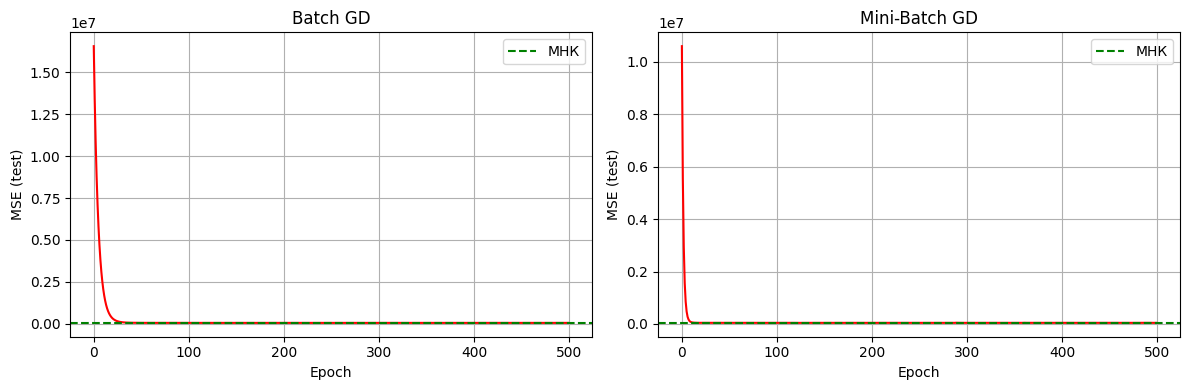


=== СРАВНЕНИЕ ===
МНК: RMSE=203.8524, R2=0.9565
Batch GD: RMSE=203.8523, R2=0.9565, время=0.6820сек
Mini-Batch: RMSE=203.1733, R2=0.9568, время=1.0190сек


In [19]:
# ============================================
# МНК (эталон)
# ============================================
w_norm = np.linalg.inv(X_train_scaled.T @ X_train_scaled) @ X_train_scaled.T @ y_train.values
rmse_norm = np.sqrt(mean_squared_error(y_test, X_test_scaled @ w_norm))
print(f'МНК: RMSE = {rmse_norm:.4f}')

# ============================================
# BATCH GD
# ============================================
print('\n=== BATCH GD ===')
start = time.time()
w_bgd = np.zeros(X_train_scaled.shape[1])
lr = 0.1
epochs = 500
bgd_loss = []

for epoch in range(epochs):
    y_pred = X_train_scaled @ w_bgd
    grad = (1/len(y_train)) * X_train_scaled.T @ (y_pred - y_train.values)
    w_bgd -= lr * grad
    bgd_loss.append(mean_squared_error(y_test, X_test_scaled @ w_bgd))

time_bgd = time.time() - start
rmse_bgd = np.sqrt(mean_squared_error(y_test, X_test_scaled @ w_bgd))
print(f'RMSE = {rmse_bgd:.4f}, время = {time_bgd:.4f} сек')

# ============================================
# MINI-BATCH GD
# ============================================
print('\n=== MINI-BATCH GD ===')
start = time.time()
w_mbgd = np.zeros(X_train_scaled.shape[1])
lr = 0.01
epochs = 500
batch_size = 5
n = len(y_train)
mbgd_loss = []

for epoch in range(epochs):
    idx = np.random.permutation(n)
    X_shuffled = X_train_scaled[idx]
    y_shuffled = y_train.values[idx]

    for i in range(0, n, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        y_pred = X_batch @ w_mbgd
        grad = (1/len(X_batch)) * X_batch.T @ (y_pred - y_batch)
        w_mbgd -= lr * grad

    mbgd_loss.append(mean_squared_error(y_test, X_test_scaled @ w_mbgd))

time_mbgd = time.time() - start
rmse_mbgd = np.sqrt(mean_squared_error(y_test, X_test_scaled @ w_mbgd))
print(f'RMSE = {rmse_mbgd:.4f}, время = {time_mbgd:.4f} сек')

# ============================================
# ГРАФИКИ
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(bgd_loss, color='red')
axes[0].axhline(y=rmse_norm**2, color='green', ls='--', label='МНК')
axes[0].set_title('Batch GD')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE (test)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(mbgd_loss, color='red')
axes[1].axhline(y=rmse_norm**2, color='green', ls='--', label='МНК')
axes[1].set_title('Mini-Batch GD')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE (test)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ============================================
# СРАВНЕНИЕ
# ============================================
print('\n=== СРАВНЕНИЕ ===')
print(f'МНК: RMSE={rmse_norm:.4f}, R2={r2_score(y_test, X_test_scaled @ w_norm):.4f}')
print(f'Batch GD: RMSE={rmse_bgd:.4f}, R2={r2_score(y_test, X_test_scaled @ w_bgd):.4f}, время={time_bgd:.4f}сек')
print(f'Mini-Batch: RMSE={rmse_mbgd:.4f}, R2={r2_score(y_test, X_test_scaled @ w_mbgd):.4f}, время={time_mbgd:.4f}сек')

**Выводы:**

Самый точный градиентный спуск - стандартный, он выдает такие же метрики, как и эталонное решение в виде МНК.

Для маленьких данных Batch GD эффективнее - как с точки зрения скорости, так и точности - в виде сравнения с эталонным решением.

Mini-Batch на маленьких данных работает в 2 раза дольше - так как за одну эпоху обновляет веса в `n / batch_size` чаще, чем классический GD.

## Задание 6

А что, если бы мы не стали удалять никакие признаки, а просто сразу применили бы **регуляризацию**? Попробуйте в рамках этого задания:
* Взять данные **без удаления мультиколлинеарных признаков** и обучить на них лучший градиентный метод из предыдущих заданий, пока **без регуляризации**. Посмотрите, как ведут себя метрики на тренировочном и тестовом наборе, а также какие веса у модели.
* Взять данные **без удаления мультиколлинеарных признаков** и обучить на них лучший градиентный метод из предыдущих заданий, **с L1- и L2-регуляризацией** по отдельности. Сравните метрики и веса с предыдущим вариантом, а также с полученными результатами в 4 и 5 заданиях.
* Что лучше: обучиться на всех данных с регуляризацией или превентивно устранять мультиколлинеарность? Для самой наилучшей модели определите, какие признаки наиболее важны при прогнозировании. Отразите итоговые рекомендации в выводе.

In [20]:
# 1. данные БЕЗ удаления мультиколлинеарных признаков
X_raw_full = df.drop('extr_per_day', axis=1)  # все признаки
y_raw = df['extr_per_day']

# делим на train/test
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_raw_full, y_raw, test_size=0.2, random_state=42
)

# масштабируем
scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_test_full_scaled = scaler_full.transform(X_test_full)

# добавляем bias
X_train_full_scaled = np.column_stack([np.ones(len(X_train_full_scaled)), X_train_full_scaled])
X_test_full_scaled = np.column_stack([np.ones(len(X_test_full_scaled)), X_test_full_scaled])

In [21]:
# ============================================
# BATCH GD на данных с мультиколлинеарностью (БЕЗ регуляризации)
# ============================================
print('\n=== BATCH GD (с мультиколлинеарностью, без регуляризации) ===')
start = time.time()

# Инициализация весов
w_full = np.zeros(X_train_full_scaled.shape[1])
lr = 0.1
epochs = 500

# Для сохранения истории
train_loss, test_loss = [], []

for epoch in range(epochs):
    # Предсказание
    y_pred_train = X_train_full_scaled @ w_full

    # Градиент (без регуляризации)
    grad = (1/len(y_train)) * X_train_full_scaled.T @ (y_pred_train - y_train.values)

    # Обновление весов
    w_full -= lr * grad

    # Сохраняем ошибки
    if epoch % 50 == 0:
        train_loss.append(mean_squared_error(y_train, y_pred_train))
        test_loss.append(mean_squared_error(y_test, X_test_full_scaled @ w_full))

time_full = time.time() - start

# ============================================
# МЕТРИКИ
# ============================================
y_pred_train = X_train_full_scaled @ w_full
y_pred_test = X_test_full_scaled @ w_full

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f'\nМЕТРИКИ:')
print(f'RMSE train = {rmse_train:.4f}')
print(f'RMSE test = {rmse_test:.4f}')
print(f'MAE test = {mae_test:.4f}')
print(f'R2 test = {r2_test:.4f}')
print(f'Время обучения = {time_full:.4f} сек')

# ============================================
# АНАЛИЗ ВЕСОВ
# ============================================
feature_names = ['bias'] + list(X_raw_full.columns)
print('\nВЕСА МОДЕЛИ:')
print('-' * 50)
for name, w in zip(feature_names, w_full):
    print(f'{name:25}: {w:10.4f}')


=== BATCH GD (с мультиколлинеарностью, без регуляризации) ===

МЕТРИКИ:
RMSE train = 197.5877
RMSE test = 208.5910
MAE test = 152.9703
R2 test = 0.9544
Время обучения = 0.0664 сек

ВЕСА МОДЕЛИ:
--------------------------------------------------
bias                     :  4322.1569
porosity                 :   642.8174
permeability             :   206.8744
acoustic_impedance       :  -159.6638
brittleness              :   365.2094
organic_carbon           :     2.6440
vitrinite_reflectance    :   194.0822


**Выводы:**

Появилось переобучение - метрики на test стали хуже.

Появилось перераспределение весов - вес ключевого признака сильно упал, при этом `permeability` забрал у него часть веса.

`organic_carbon` - незначимый признак.

Поэтому всегда лучше сначала устранять мультиколлениарность - чтобы избежать переобучения и для стабильности самой модели - чтобы она не терялась, какой признак более значим.

## Задание 7*

Попробуйте добавить еще больше эффективных модификаций и проверить их экспериментально:
* Реализуйте вручную алгоритм RMSProp (можете вспомнить AdaGrad и модифицировать его).
* Добавьте в него механизм ранней остановки через флаг в аргументе функции. Задайте опциональные гиперпараметры количества итераций без улучшения и пороговую разность значений ошибки на соседних итерациях.
* Поэкспериментируйте с гиперпараметрами и постарайтесь получить еще большее качество. Запишите наблюдения в выводе.

> **Справка по адаптивным градиентным методам:**

* $g_t = \nabla_{\theta} L(\theta_t)$ — градиент функции потерь
* $\varepsilon$ — малая константа для численной стабильности
* $\beta$ — коэффициент сглаживания


**Adagrad:** шаг обучения уменьшается для параметров с большими градиентами.

$$
G_t = G_{t-1} + g_t \odot g_t
$$

$$
\theta_{t+1} = \theta_t
\frac{\eta}{\sqrt{G_t} + \varepsilon}
\odot
g_t
$$


**RMSprop:** исправляет затухание шага в Adagrad за счет экспоненциального усреднения.

$$
v_t = \beta v_{t-1} + (1 - \beta), g_t \odot g_t
$$

$$
\theta_{t+1} = \theta_t
\frac{\eta}{\sqrt{v_t} + \varepsilon}
\odot
g_t
$$


In [22]:
# RMSProp с ранней остановкой

class RMSProp:
    def __init__(self, lr=0.01, beta=0.9, eps=1e-8):
        self.lr = lr
        self.beta = beta
        self.eps = eps
        self.v = None

    def step(self, w, grad):
        if self.v is None:
            self.v = np.zeros_like(grad)
        self.v = self.beta * self.v + (1 - self.beta) * grad**2
        w -= self.lr * grad / (np.sqrt(self.v) + self.eps)
        return w

def train_rmsprop(X_train, y_train, X_val, y_val,
                  lr=0.01, beta=0.9, epochs=1000,
                  early_stop=True, patience=50, tol=1e-4):

    w = np.zeros(X_train.shape[1])
    w[0] = y_train.mean()  # bias инициализация
    opt = RMSProp(lr=lr, beta=beta)

    best_w = w.copy()
    best_loss = np.inf
    patience_cnt = 0
    losses = []

    for epoch in range(epochs):
        grad = (X_train.T @ (X_train @ w - y_train)) / len(y_train)
        w = opt.step(w, grad)

        val_loss = np.mean((X_val @ w - y_val)**2)
        losses.append(val_loss)

        if early_stop:
            if val_loss < best_loss - tol:
                best_loss = val_loss
                best_w = w.copy()
                patience_cnt = 0
            else:
                patience_cnt += 1

            if patience_cnt >= patience:
                print(f'Ранняя остановка на эпохе {epoch}')
                break

    return best_w, losses

{'lr': 0.5, 'beta': 0.9, 'patience': 50}
{'lr': 1.0, 'beta': 0.9, 'patience': 50}
Ранняя остановка на эпохе 910
{'lr': 1.0, 'beta': 0.95, 'patience': 50}
Ранняя остановка на эпохе 943
{'lr': 1.0, 'beta': 0.99, 'patience': 50}
{'lr': 1.0, 'beta': 0.9, 'patience': 100}
Ранняя остановка на эпохе 960


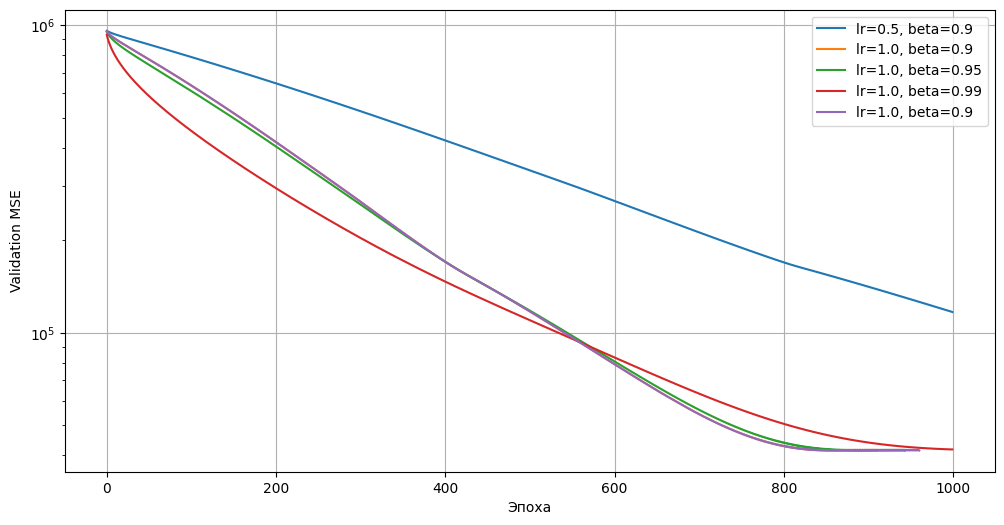

In [23]:
# эксперименты с гиперпараметрами

params_grid = [
    {'lr': 0.5, 'beta': 0.9, 'patience': 50},
    {'lr': 1.0, 'beta': 0.9, 'patience': 50},
    {'lr': 1.0, 'beta': 0.95, 'patience': 50},
    {'lr': 1.0, 'beta': 0.99, 'patience': 50},
    {'lr': 1.0, 'beta': 0.9, 'patience': 100},
]

results = []
plt.figure(figsize=(12, 6))

for params in params_grid:
    print(f'{params}')
    w, losses = train_rmsprop(
        X_train_scaled, y_train, X_test_scaled, y_test,
        lr=params['lr'], beta=params['beta'],
        patience=params['patience']
    )

    y_pred = X_test_scaled @ w
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({**params, 'mse': mse, 'r2': r2})
    plt.plot(losses, label=f'lr={params['lr']}, beta={params['beta']}')

plt.xlabel('Эпоха')
plt.ylabel('Validation MSE')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()

In [24]:
# результаты

print('Сводная таблица результатов')
for r in sorted(results, key=lambda x: x['mse']):
    print(f'lr={r['lr']:.2f}, beta={r['beta']:.2f}, patience={r['patience']}:'
          f'MSE={r['mse']:.2f}, R2={r['r2']:.4f}')

best = min(results, key=lambda x: x['mse'])
print(f'Лучший результат: {best}')
print(f'MSE: {best['mse']:.2f}, R2: {best['r2']:.4f}')

# сравнение с базовым SGD
w_sgd = np.zeros(X_train_scaled.shape[1])
w_sgd[0] = y_train.mean()
lr_sgd = 0.01
for _ in range(500):
    grad = (X_train_scaled.T @ (X_train_scaled @ w_sgd - y_train)) / len(y_train)
    w_sgd -= lr_sgd * grad

y_pred_sgd = X_test_scaled @ w_sgd
print(f'SGD baseline: MSE={mean_squared_error(y_test, y_pred_sgd):.2f}')

Сводная таблица результатов
lr=1.00, beta=0.95, patience=50:MSE=41382.76, R2=0.9567
lr=1.00, beta=0.90, patience=50:MSE=41396.57, R2=0.9566
lr=1.00, beta=0.90, patience=100:MSE=41396.57, R2=0.9566
lr=1.00, beta=0.99, patience=50:MSE=41775.98, R2=0.9562
lr=0.50, beta=0.90, patience=50:MSE=116835.59, R2=0.8776
Лучший результат: {'lr': 1.0, 'beta': 0.95, 'patience': 50, 'mse': 41382.764596912704, 'r2': 0.9566608360017388}
MSE: 41382.76, R2: 0.9567
SGD baseline: MSE=43154.97


**Выводы:**

Самая лучшая модель - RMSProp с ранней остановкой.

Это достигается за счет правильно подобранных гиперпараметров - и в итоге эта модель обгоняет по метрикам даже МНК!

Ранняя остановка при этом помогла избежать переобучения.

Лучшие гиперпараметры, подобранные экспериментально:

- lr = 1.00

- beta = 0.95

- patience = 50